# SARIMA and LSTM Forecasting for Low Birth Weight and Prematurity


### What does this notebook do?
This notebook forecasts monthly health indicators using two complementary approaches: **SARIMA** for statistical time-series modeling and **LSTM** for recurrent neural-network modeling.

The same workflow supports either selected indicator:

- Low birth weight index, converted to cases per 1,000 live births.
- Prematurity index, kept as percentage of live births.

The notebook is organized as a reproducible pipeline: configuration, data loading, validation, exploratory plots, SARIMA modeling, LSTM modeling, and multi-horizon forecast diagnostics.


## Methodological Decisions

The main modeling choices in this notebook are documented here to make the analysis easier to audit and reproduce.

- **Indicator standardization.** The raw CSV files use percentage-based indicator columns. Low birth weight is converted to cases per 1,000 live births to match the intended interpretation of the index; prematurity is kept as percentage of live births. The raw Portuguese column names are renamed to English labels for consistency in tables and outputs.
- **Monthly time index.** The analysis uses complete monthly observations from January 2013 through December 2023. This fixed range makes seasonality comparable across years and supports a 12-month holdout design.
- **Train/test split.** Observations through December 2022 are used for model fitting, and all 12 months of 2023 are reserved for out-of-sample evaluation. This mimics a real forecasting setting where the final year is unknown during model training.
- **SARIMA specification.** SARIMA is used as the interpretable statistical benchmark. The differencing orders are guided by ADF/KPSS diagnostics and seasonal strength, while the finite parameter grid is intentionally limited to low-order models to reduce overfitting, convergence failures, and unnecessary complexity.
- **LSTM preprocessing.** LSTM models use only the training period to fit the scaler, avoiding leakage from the 2023 holdout. A 12-month lookback is used as the baseline because the data are monthly and yearly seasonality is plausible.
- **LSTM variants.** Baseline, grid-search, regularized, transformed, and multi-horizon LSTM experiments share one unified training pipeline. Variants differ only by parameters such as lookback, units, dropout, L2 regularization, early stopping, and transformation.
- **Evaluation metrics.** MAE, RMSE, and MAPE are reported together because they capture complementary aspects of forecast error: average absolute error, error magnitude with higher penalty for large misses, and percentage-scale error.
- **Final comparison.** The final model table ranks models by RMSE because larger errors are especially relevant in forecasting validation. MAE and MAPE remain visible to avoid relying on a single metric.
- **Reproducibility.** Random seeds, dependency management, structured CSV/JSON outputs, and lightweight tests are included so the notebook can be rerun and audited more reliably.

## 0. Global Configuration and Reproducibility


In [2]:
import logging
import os
import sys
from pathlib import Path

# Explicitly set PROJECT_ROOT to /content as is typical in Colab
PROJECT_ROOT = Path("/content")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Ensure the 'abep_forecasting' package is recognized by creating __init__.py if it doesn't exist
ABEP_FORECASTING_DIR = SRC_DIR / "abep_forecasting"
ABEP_FORECASTING_DIR.mkdir(parents=True, exist_ok=True) # Ensure the directory exists
init_file = ABEP_FORECASTING_DIR / "__init__.py"
if not init_file.exists():
    init_file.touch() # Create an empty __init__.py file
    print(f"Created empty __init__.py at {init_file} to make abep_forecasting a package.")


from abep_forecasting.config import (
    DATE_COLUMN,
    FORECAST_YEAR,
    INDICATOR_CONFIGS,
    SEASONAL_PERIOD,
    SEED,
    START_YEAR,
    TEST_YEAR,
    TRAIN_END_YEAR,
    IndicatorConfig,
    resolve_data_source,
)

LOG_LEVEL = os.getenv("LOG_LEVEL", "INFO").upper()
logging.basicConfig(
    level=getattr(logging, LOG_LEVEL, logging.INFO),
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
logger = logging.getLogger("abep_forecasting")

indicator_choice = "Low Birth Weight" # @param ["Low Birth Weight", "Prematurity"]

config = INDICATOR_CONFIGS[indicator_choice]
DATA_SOURCE = resolve_data_source(config);

CSV_FILE = config.source_url
VALUE_COL = config.value_col
TARGET_LABEL = config.target_label
Y_AXIS_LABEL = config.y_axis_label
OUTPUT_DIR = Path("output")
TABLE_DIR = OUTPUT_DIR / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
output_dir = str(OUTPUT_DIR)  # Backward-compatible name used by later cells.

logger.info("Selected indicator: %s", indicator_choice)
logger.info("Resolved data source: %s", DATA_SOURCE)
logger.info("Target column: %s", VALUE_COL)


00:31:23 | INFO | abep_forecasting | Selected indicator: Low Birth Weight
00:31:23 | INFO | abep_forecasting | Resolved data source: https://raw.githubusercontent.com/fjmeneguini/TCC/refs/heads/main/data/processed/series_temporais/vw_indice_baixo_peso_mensal.csv
00:31:23 | INFO | abep_forecasting | Target column: low_birth_weight_index


## 1. Dependencies
Run this cell only when the runtime does not already have the required packages installed. Dependencies are managed in `requirements.txt` to keep the notebook and environment definition consistent.

In [1]:
# Colab/runtime setup. Skip this cell when dependencies are already installed.
!pip -q install -r requirements.txt

In [3]:
from __future__ import annotations

import logging
import os
import warnings
from functools import partial
from itertools import product
from pathlib import Path

_CACHE_DIR = Path("output/.cache")
_MPL_CACHE_DIR = _CACHE_DIR / "matplotlib"
_FONTCONFIG_CACHE_DIR = _CACHE_DIR / "fontconfig"
_MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_FONTCONFIG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(_CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_CACHE_DIR))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tabulate import tabulate

tf.get_logger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.style.use("seaborn-v0_8-whitegrid")

from abep_forecasting.comparison import (
    append_comparison_row,
    build_final_model_comparison as _build_final_model_comparison,
    metrics_from_result,
)
from abep_forecasting.data import (
    STANDARD_COLUMN_NAMES,
    SplitData,
    load_indicator_data,
    prepare_monthly_split,
    show_split_info as _show_split_info,
    validate_monthly_csv,
    validate_monthly_dataframe,
)
from abep_forecasting.io_utils import (
    model_metrics_frame,
    output_path as _output_path,
    result_path as _result_path,
    save_json as _save_json,
    save_table as _save_table,
    slugify,
)
from abep_forecasting.lstm import (
    LSTMPreparedData,
    apply_series_transform,
    build_lstm_fit_inputs,
    build_lstm_model,
    build_lstm_model_regularized,
    create_sequences,
    evaluate_lstm_multi_horizon,
    generate_lstm_multi_horizon_forecasts,
    grid_search_lstm_regularization,
    grid_search_lstm_split,
    invert_lstm_predictions,
    invert_series_transform,
    make_lstm_comparison_table,
    prepare_lstm_training_data,
    recursive_forecast,
    recursive_forecast_12m,
    recursive_forecast_multi_horizon,
    run_lstm_experiment,
    run_lstm_pipeline,
    run_lstm_pipeline_split,
    run_lstm_pipeline_split_regularized,
    run_lstm_pipeline_split_regularized_transformed,
    set_seeds,
    summarize_lstm_holdout,
    summarize_lstm_horizon_metrics,
)
from abep_forecasting.metrics import get_mean_errors, maerr, mape, mse, rmse
from abep_forecasting.plots import (
    generate_lstm_rolling_outputs,
    generate_rolling_forecasts,
    get_month_series,
    plot_decomposition as _plot_decomposition,
    plot_error_heatmap,
    plot_lstm_error_heatmap,
    plot_lstm_rolling_comparison,
    plot_multi_horizon_forecasts,
    plot_rolling_comparison,
)
from abep_forecasting.sarima import (
    ModelResult,
    adjust_one_sarima,
    ensure_datetime_series,
    forecast_metrics,
    generate_final_pipeline,
    generate_sarima_report,
    grid_search_sarima,
    run_and_plot_sarima as _run_and_plot_sarima,
    seasonal_strength_stl,
    stationarity_diagnostic,
    suggest_d_D,
    test_adf,
    test_kpss,
    test_ljungbox_residuals,
)

output_path = partial(_output_path, output_dir=OUTPUT_DIR)
result_path = partial(_result_path, table_dir=TABLE_DIR, indicator_choice=indicator_choice)
save_table = partial(_save_table, table_dir=TABLE_DIR, indicator_choice=indicator_choice)
save_json = partial(_save_json, table_dir=TABLE_DIR, indicator_choice=indicator_choice)
show_split_info = partial(_show_split_info, logger=logger)
plot_decomposition = partial(_plot_decomposition, output_dir=OUTPUT_DIR)
run_and_plot_sarima = partial(_run_and_plot_sarima, ylabel=Y_AXIS_LABEL)

set_seeds(SEED)


00:32:25 | INFO | numexpr.utils | NumExpr defaulting to 2 threads.


## 2. Data Source


## 3. Loading the Selected Monthly Series


The selected CSV is loaded, the reference month is parsed as a date, and the indicator column is standardized for the downstream pipeline.


In [4]:
df_selected = load_indicator_data(DATA_SOURCE, config)
df_raw = df_selected.copy()


In [5]:
# Quick structural overview before modeling.
print("--- Data Summary (info) ---")
df_selected.info()

print("\n--- Descriptive Statistics (describe) ---")
display(df_selected.describe())


--- Data Summary (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   reference_month         132 non-null    datetime64[ns]
 1   year                    132 non-null    int64         
 2   month                   132 non-null    int64         
 3   total_births            132 non-null    int64         
 4   total_low_birth_weight  132 non-null    int64         
 5   low_birth_weight_index  132 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 6.3 KB

--- Descriptive Statistics (describe) ---


,reference_month,year,month,total_births,total_low_birth_weight,low_birth_weight_index
count,132,132.000000,132.000000,132.000000,132.000000,132.000000
mean,2018-06-16 13:27:16.363636480,2018.000000,6.500000,234720.537879,20422.772727,87.226515
min,2013-01-01 00:00:00,2013.000000,1.000000,190836.000000,17459.000000,79.400000
25%,2015-09-23 12:00:00,2015.000000,3.750000,221460.000000,19567.250000,84.375000
50%,2018-06-16 00:00:00,2018.000000,6.500000,234249.000000,20432.500000,86.100000
75%,2021-03-08 18:00:00,2021.000000,9.250000,246806.500000,21237.250000,89.325000
max,2023-12-01 00:00:00,2023.000000,12.000000,277540.000000,23308.000000,99.700000
std,NaN,3.174324,3.465203,18593.052076,1246.512764,4.277312


**Selected monthly indicator**


In [6]:
display(df_selected.head())

,reference_month,year,month,total_births,total_low_birth_weight,low_birth_weight_index
0,2013-01-01,2013,1,245038,21105,86.1
1,2013-02-01,2013,2,229857,19849,86.4
2,2013-03-01,2013,3,255273,22259,87.2
3,2013-04-01,2013,4,256677,21921,85.4
4,2013-05-01,2013,5,262954,21993,83.6


#### Time Series - Selected Monthly Indicator - Period: 2013-2023


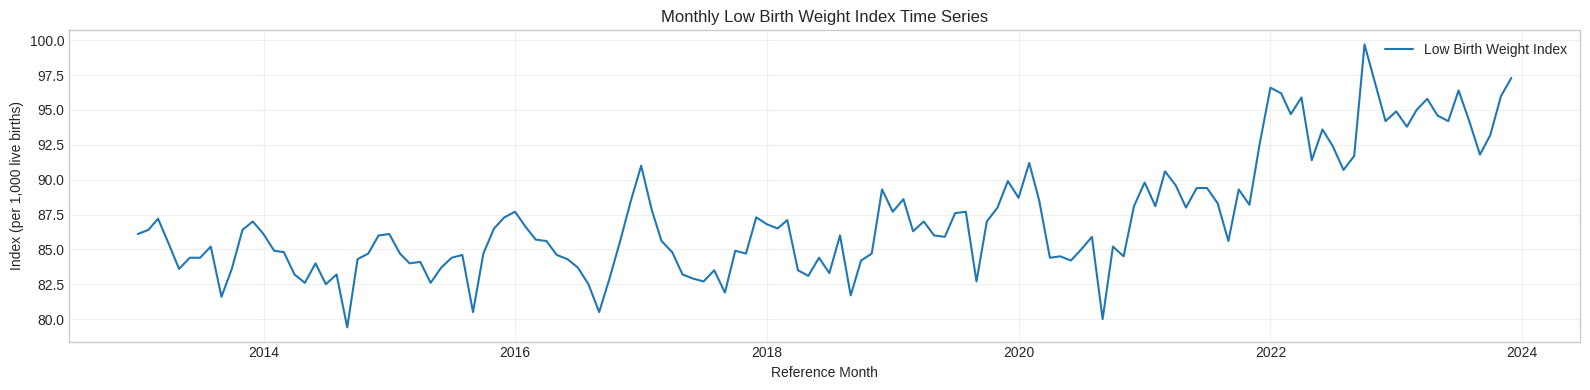

In [7]:
df_plot = df_selected.copy()

start_date = pd.Timestamp(f"{START_YEAR}-01-01")
end_date = pd.Timestamp(f"{TEST_YEAR}-12-01")
df_plot = df_plot[df_plot[DATE_COLUMN].between(start_date, end_date)]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_plot[DATE_COLUMN], df_plot[VALUE_COL], label=TARGET_LABEL, color="#1f77b4")
ax.set_title(f"Monthly {TARGET_LABEL} Time Series")
ax.set_xlabel("Reference Month")
ax.set_ylabel(Y_AXIS_LABEL)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(output_path(f"monthly_{slugify(TARGET_LABEL)}_time_series.pdf"), bbox_inches="tight")
plt.show()


#### Monthly Comparison: 2013 vs 2023


00:33:06 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:33:06 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:33:06 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:33:06 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


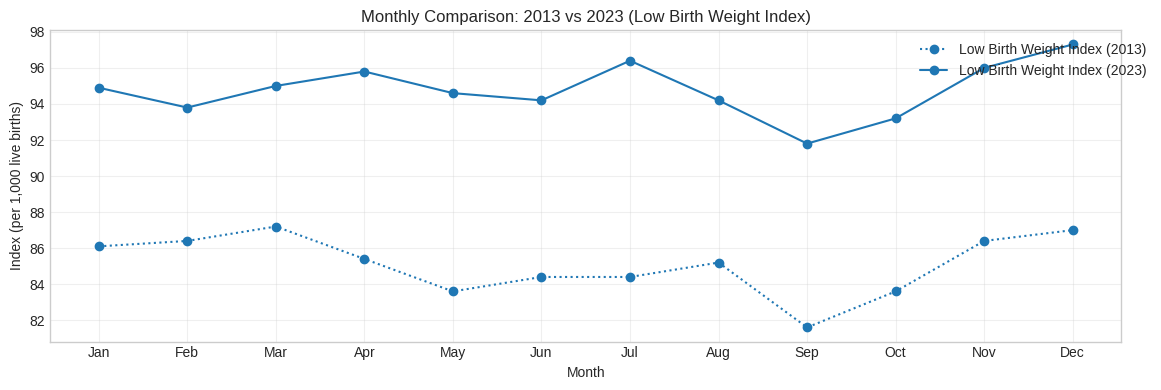

In [8]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(months, get_month_series(df_selected, START_YEAR, VALUE_COL), label=f"{TARGET_LABEL} ({START_YEAR})", color="#1f77b4", linestyle=":", marker="o")
ax.plot(months, get_month_series(df_selected, TEST_YEAR, VALUE_COL), label=f"{TARGET_LABEL} ({TEST_YEAR})", color="#1f77b4", linestyle="-", marker="o")
ax.set_title(f"Monthly Comparison: {START_YEAR} vs {TEST_YEAR} ({TARGET_LABEL})")
ax.set_xlabel("Month")
ax.set_ylabel(Y_AXIS_LABEL)
ax.legend(bbox_to_anchor=(0.8, 1), loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(output_path(f"monthly_comparison_{slugify(indicator_choice)}_{START_YEAR}_{TEST_YEAR}.pdf"), bbox_inches="tight")
plt.show()


## 4. Validation of Structure, Dates, and Monthly Coverage

Check if the file has 132 rows, if the series ranges from 2013-01 to 2023-12, and if the expected monthly frequency is complete.

#### Procedure

In [9]:
EXPECTED_RANGE = pd.date_range(f"{START_YEAR}-01-01", f"{TEST_YEAR}-12-01", freq="MS")
validate_monthly_csv = validate_monthly_dataframe  # Backward-compatible alias.


#### Execution - Selected Indicator


In [10]:
summary_report = validate_monthly_dataframe(df_selected, indicator_choice)
display(summary_report)
save_table(summary_report, "validation_summary")


**=== Validation: Low Birth Weight ===**

| Item            | Value                                                                                                                                                     |
|-----------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------|
| Rows            | 132                                                                                                                                                       |
| Minimum Date    | 2013-01-01                                                                                                                                                |
| Maximum Date    | 2023-12-01                                                                                                                                                |
| Column Types    | reference_month: datetime64[ns]<br>year: int64<br>month: int64<br>total_births: int64<br>total_low_birth_weight: int64<br>low_birth_weight_index: float64 |
| Expected Months | 132                                                                                                                                                       |
| Observed Months | 132                                                                                                                                                       |
| Missing Months  | 0                                                                                                                                                         |
| Extra Months    | 0                                                                                                                                                         |

,name,rows,min_date,max_date,expected_months,observed_months,missing_months,extra_months
0,Low Birth Weight,132,2013-01-01,2023-12-01,132,132,0,0


00:33:06 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_validation_summary.csv


PosixPath('output/tables/low_birth_weight_validation_summary.csv')

## 5. Preparation of Time Series for Modeling

Sort the data by `reference_month`, define the temporal index, and split into training (up to 2022) and test (2023).

#### Procedure

In [11]:
split_data = prepare_monthly_split(df_selected, VALUE_COL)
show_split_info(indicator_choice, split_data)


00:33:06 | INFO | abep_forecasting | Low Birth Weight preparation summary
00:33:06 | INFO | abep_forecasting | Total observations: 132
00:33:06 | INFO | abep_forecasting | Training set up to 2022: 120 months
00:33:06 | INFO | abep_forecasting | Test set 2023: 12 months


#### Execution - Selected Indicator


In [12]:
# Re-display split information after the modeling object has been created.
show_split_info(indicator_choice, split_data)


00:33:06 | INFO | abep_forecasting | Low Birth Weight preparation summary
00:33:06 | INFO | abep_forecasting | Total observations: 132
00:33:06 | INFO | abep_forecasting | Training set up to 2022: 120 months
00:33:06 | INFO | abep_forecasting | Test set 2023: 12 months


In [13]:
stats = df_selected[VALUE_COL].describe().to_frame().T
stats.index = [TARGET_LABEL]

stats_rounded = stats.round(2)
display(Markdown(f"### Descriptive Statistics: {TARGET_LABEL}"))
display(stats_rounded)
save_table(stats_rounded, "descriptive_statistics", index=True)


### Descriptive Statistics: Low Birth Weight Index

,count,mean,std,min,25%,50%,75%,max
Low Birth Weight Index,132.0,87.23,4.28,79.4,84.38,86.1,89.32,99.7


00:33:06 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_descriptive_statistics.csv


PosixPath('output/tables/low_birth_weight_descriptive_statistics.csv')

### 5.2 Verification of Statistical Properties

For the application of time series models such as ARIMA and LSTM, it is fundamental to previously evaluate certain statistical properties of the series, as each approach has distinct assumptions and methodological implications. Proper validation of these properties is essential to ensure inferential consistency (for ARIMA) and predictive performance (for LSTM).

Initially, in the context of ARIMA (AutoRegressive Integrated Moving Average) models, there are classical statistical assumptions that must be verified. The primary one is the **stationarity** of the time series. A stationary series presents constant mean, variance, and autocovariance over time. If the original series is not stationary, it is necessary to apply transformations, such as differencing (the *d* order of ARIMA), logarithms, or trend removal. Formal tests such as the **Augmented Dickey-Fuller (ADF)** or **KPSS** are usually employed for this verification.

Furthermore, ARIMA assumes a linear structure in the data, implying that temporal dependence patterns must be capturable by linear combinations of lags. In this sense, it is important to analyze the autocorrelation (ACF) and partial autocorrelation (PACF) functions to identify parameters *p* (autoregressive) and *q* (moving average). Another relevant aspect is the **normality and independence of residuals**, which must be checked after model adjustment, typically via tests like Ljung-Box.

**Seasonality** is an important component and must be validated. If a seasonal pattern exists (e.g., monthly with periodicity 12), the model should be extended to a **SARIMA (Seasonal ARIMA)**, incorporating seasonal parameters (*P, D, Q, s*). Seasonality identification can be done through visual inspection, series decomposition (classical or STL), or ACF analysis (peaks at multiples of the periodicity).

In the case of recurrent neural network models, such as LSTM (Long Short-Term Memory), the assumptions are significantly more flexible. LSTM does not require stationarity or linearity, being capable of capturing non-linear relationships and long-term dependencies. However, this does not eliminate the need for exploratory data analysis.

Although it is not mandatory to make the series stationary for LSTM, it is highly recommended to perform **data normalization or standardization**, as neural networks are sensitive to scale. Additionally, the presence of trend and seasonality can influence model performance. In many cases, techniques like **series decomposition** (trend, seasonality, and residuals) can be used to improve modeling, either by feeding the model with separate components or by removing dominant patterns to facilitate learning.

Another relevant aspect for LSTM is the definition of the input structure, i.e., the lookback window size. This choice depends directly on the existence of seasonal patterns or cycles in the series. Therefore, seasonality identification is also useful for this type of model, even if it is not a formal requirement.

Finally, LSTM models require a larger volume of data for adequate generalization. Very short series tend to favor statistical models like ARIMA. Long series, with complex and non-linear patterns, are more suitable for neural networks.

In summary, for ARIMA, it is essential to validate stationarity, autocorrelation, and seasonality, while ensuring adequate residuals. For LSTM, although there is no formal requirement for these properties, the analysis of trend, seasonality, and data scale remains fundamental for defining the architecture and improving model performance.

### 5.2.1 Seasonal Decomposition Plot (trend, seasonal, residual)

#### Procedure

In [14]:
# Decomposition plotting is implemented in abep_forecasting.plots.plot_decomposition.


#### Series Decomposition - Selected Indicator


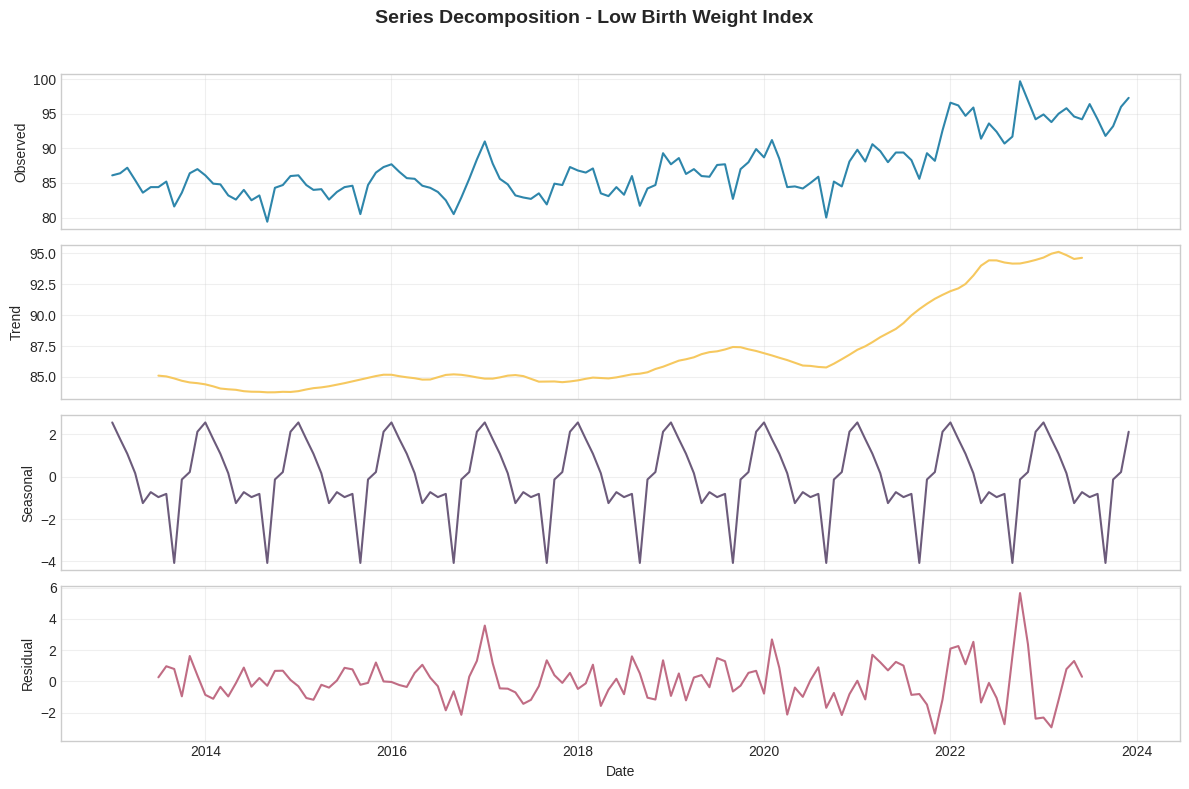

In [15]:
plot_decomposition(
    series=split_data.full[VALUE_COL],
    title=f"Series Decomposition - {TARGET_LABEL}",
    filename=f"decomposition_{slugify(indicator_choice)}.pdf",
    figsize=(12, 8),
)


### 5.2.2 ADF and KPSS Tests

#### Procedure - SARIMA Parameter Search


In [16]:
# SARIMA diagnostics, grid search, and report generation are implemented in abep_forecasting.sarima.


**Justification for the Search Space Choice**

The definition of the search space for the SARIMA model parameters was done deliberately to balance statistical rigor, model parsimony, and computational feasibility. Specifically, values for (p, q in {0,1,2,3}) and (P, Q in {0,1,2}) were considered, defining a finite set of candidate models to be evaluated via grid search.

This choice is based, first, on the principle of parsimony in the Box-Jenkins methodology. High-order models tend towards overfitting, numerical instability, and loss of out-of-sample generalization. In empirical applications involving demographic or epidemiological series, low-order structures are often sufficient to capture temporal dependencies.

Additionally, restricting the search space contributes to estimation robustness. High-order SARIMA models often face convergence difficulties. Limiting parameters acts as implicit regularization, favoring stable and interpretable models. From a computational standpoint, grid search has combinatorial complexity; these limits make the procedure feasible while maintaining a broad enough range to explore dependency structures.

It is important to note that the final selection was not based solely on information criteria (AIC, BIC), but also incorporated out-of-sample performance (MAE, RMSE, MAPE) and residual diagnostics (Ljung-Box). While the search space is not exhaustive, this strategy is widely accepted in literature for obtaining reliable and interpretable models.

#### Statistical Tests and SARIMA Grid Search


In [17]:
report = grid_search_sarima(
    series=split_data.full[VALUE_COL],
    name=f"Parameter Search for SARIMA - {TARGET_LABEL}",
    period=SEASONAL_PERIOD,
    test_size=12,
    p_values=(0, 1, 2, 3),
    q_values=(0, 1, 2, 3),
    P_values=(0, 1, 2),
    Q_values=(0, 1, 2),
    trend="n",
)

print(generate_sarima_report(report))
display(report["top_models"])

save_table(report["top_models"], "sarima_top_models")
save_table(report["all_models"], "sarima_all_models")
save_json({
    "series_name": report["series_name"],
    "seasonal_period": report["seasonal_period"],
    "seasonal_strength": report["seasonal_strength"],
    "original_diagnostic": report["original_diagnostic"],
    "suggestion_d_D": report["suggestion_d_D"],
    "best_model": report["best_model"],
}, "sarima_model_selection")


An analysis was performed for series 'Parameter Search for SARIMA - Low Birth Weight Index' with 132 observations, of which 120 were used for fitting and 12 reserved for out-of-sample evaluation.

On the training series, the ADF test showed a p-value of 0.9976, while the KPSS test showed a p-value of 0.0100. Together, these results indicated a diagnostic status of 'non_stationary'.

STL decomposition indicated seasonal strength of 0.7115, which was considered in defining the model's seasonal structure.

The analysis of candidate transformations suggested the combination d=1 and D=0, as it presented the best balance between stationarity and parsimony.

In the grid search, the selected model was SARIMA(0, 1, 2)x(2, 0, 2, 12), with AIC=371.95, BIC=389.60, MAE=1.2961, RMSE=1.8295, MAPE=1.37% and Ljung-Box p-value on residuals=0.8383.

The Ljung-Box test applied to the residuals did not reject the hypothesis of absence of residual autocorrelation, favoring the statistical adequacy of the ch

,order,seasonal_order,aic,bic,mae,rmse,mape,lb_pvalue,converged,n_params,residuals_ok,score
0,"(0, 1, 2)","(2, 0, 2, 12)",371.946979,389.599499,1.296098,1.829484,1.374560,0.838266,True,7,True,11.50
1,"(0, 1, 2)","(1, 0, 2, 12)",372.464500,387.595232,1.423657,1.913211,1.511249,0.052303,True,6,True,13.00
2,"(1, 1, 1)","(2, 0, 2, 12)",377.723566,395.451763,1.276980,1.768590,1.354894,0.624566,True,7,True,17.95
3,"(1, 1, 2)","(2, 0, 2, 12)",373.287502,393.461810,1.404833,1.976043,1.490032,0.711069,True,8,True,17.95
4,"(0, 1, 3)","(2, 0, 2, 12)",370.496496,390.583373,1.465065,2.097703,1.553353,0.980875,True,8,True,25.10
5,"(2, 1, 2)","(2, 0, 2, 12)",375.267626,397.963723,1.434587,2.011415,1.521559,0.728158,True,9,True,26.30
6,"(1, 1, 3)","(2, 0, 2, 12)",372.467892,395.065628,1.453594,2.080986,1.541113,0.965566,True,9,True,27.50
7,"(0, 1, 3)","(1, 0, 2, 12)",371.589621,389.165637,1.606728,2.109137,1.705100,0.051510,True,7,True,29.75
8,"(3, 1, 3)","(2, 0, 2, 12)",376.048008,403.667463,1.343951,1.947467,1.423864,0.419315,True,11,True,30.25
9,"(3, 1, 1)","(2, 0, 2, 12)",376.516353,399.212450,1.505743,2.047096,1.597104,0.672391,True,9,True,31.50


00:34:05 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_top_models.csv
00:34:05 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_all_models.csv
00:34:05 | INFO | abep_forecasting | Saved JSON: output/tables/low_birth_weight_sarima_model_selection.json


PosixPath('output/tables/low_birth_weight_sarima_model_selection.json')

## 6. SARIMA Modeling

### 6.1 Index Prediction with SARIMA


00:34:05 | INFO | abep_forecasting | Processing SARIMA model for Low Birth Weight


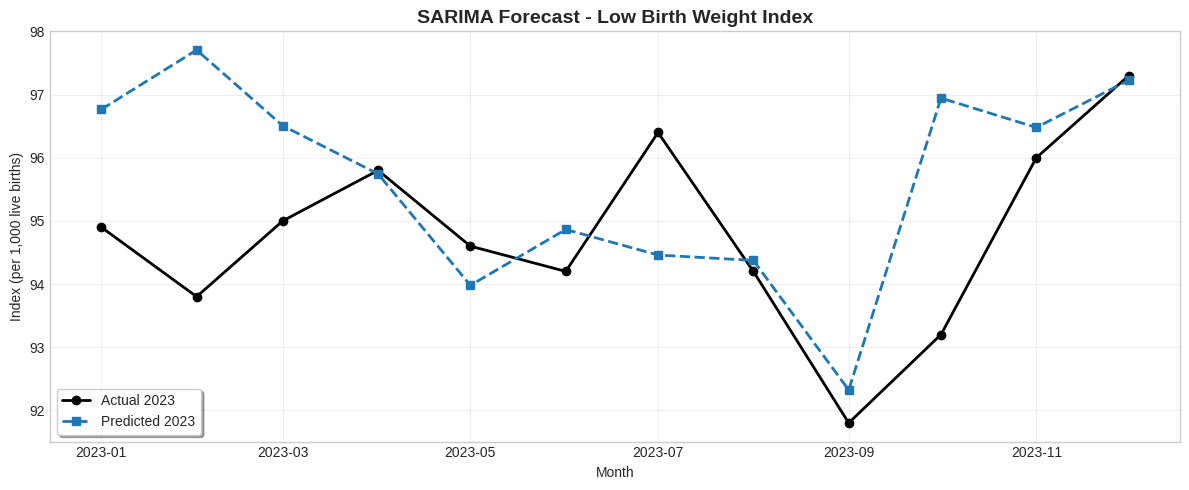

Metrics for Low Birth Weight Index:
MAE: 1.30 | RMSE: 1.83 | MAPE: 1.37%


In [18]:
logger.info("Processing SARIMA model for %s", indicator_choice)
best_params = report["best_model"]
res, mae_val, rmse_val, mape_val = run_and_plot_sarima(split_data, best_params, TARGET_LABEL)


## 7. Comparative Tables and Error Metrics (SARIMA)

#### Procedure

In [19]:
# Final SARIMA tables are generated by abep_forecasting.sarima.generate_final_pipeline.


#### Generate forecast and tables generically


In [20]:
y_pred_2023 = res.get_forecast(steps=len(split_data.test_2023)).predicted_mean
y_pred_2023.index = split_data.test_2023.index
m_table, c_table, f_table = generate_final_pipeline(split_data.full[VALUE_COL], split_data, best_params, y_pred_2023, indicator_choice)

save_table(m_table, "sarima_metrics_2023")
save_table(c_table, "sarima_comparison_2023")
save_table(f_table, "sarima_forecast_2024")

display(Markdown(f"#### 1. Indicator: {indicator_choice}"))
display(Markdown(f"**Validation Metrics ({TEST_YEAR}):**"))
display(m_table)
display(Markdown(f"**Monthly Comparison {TEST_YEAR}:**"))
display(c_table)
display(Markdown(f"**Projections for {FORECAST_YEAR}:**"))
display(f_table)


00:34:06 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_metrics_2023.csv
00:34:06 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_comparison_2023.csv
00:34:06 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_forecast_2024.csv


#### 1. Indicator: Low Birth Weight

**Validation Metrics (2023):**

,Indicator,MAE,RMSE,MAPE (%)
0,Low Birth Weight,1.3,1.8,1.4%


**Monthly Comparison 2023:**

,Month,Actual,Predicted,Absolute Error
0,2023-01,94.9,96.77,1.9
1,2023-02,93.8,97.71,3.9
2,2023-03,95.0,96.51,1.5
3,2023-04,95.8,95.74,0.1
4,2023-05,94.6,93.98,0.6
5,2023-06,94.2,94.86,0.7
6,2023-07,96.4,94.46,1.9
7,2023-08,94.2,94.37,0.2
8,2023-09,91.8,92.32,0.5
9,2023-10,93.2,96.94,3.7


**Projections for 2024:**

,Month,Low Birth Weight Projection
0,2024-01,97.2
1,2024-02,96.6
2,2024-03,96.2
3,2024-04,95.6
4,2024-05,94.7
5,2024-06,95.1


## 8. Real vs. Predicted Series Plot (SARIMA)

#### Procedure

In [21]:
# Rolling SARIMA forecasts and diagnostic plots are implemented in abep_forecasting.plots.


#### Selected Indicator


00:34:06 | INFO | abep_forecasting | Generating SARIMA rolling forecasts and heatmaps for Low Birth Weight
00:34:13 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_rolling_forecasts_2023.csv
00:34:13 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_rolling_absolute_errors_2023.csv
00:34:13 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_sarima_rolling_percentage_errors_2023.csv


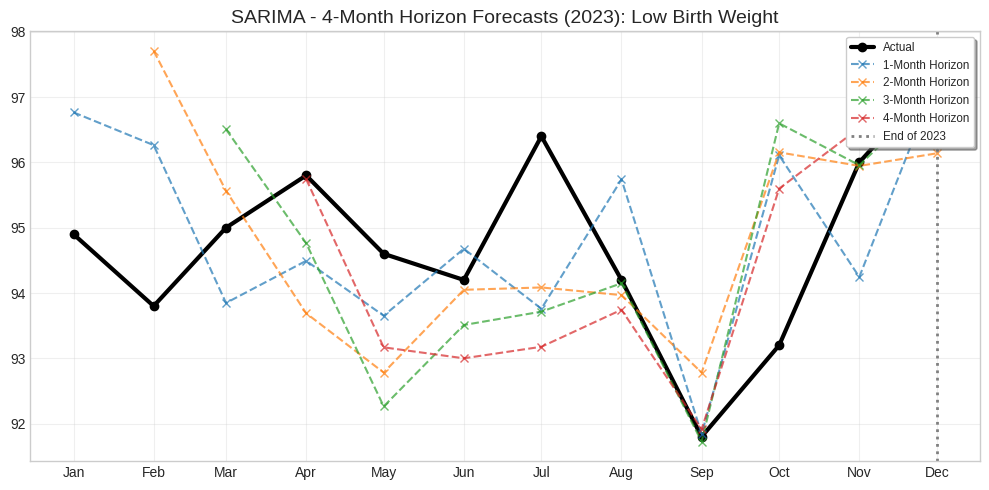

In [22]:
logger.info("Generating SARIMA rolling forecasts and heatmaps for %s", indicator_choice)
roll_df, heat_abs, heat_pct = generate_rolling_forecasts(split_data.full[VALUE_COL], best_params)

save_table(roll_df, "sarima_rolling_forecasts_2023", index=True)
save_table(heat_abs, "sarima_rolling_absolute_errors_2023")
save_table(heat_pct, "sarima_rolling_percentage_errors_2023")

plot_rolling_comparison(split_data.full[VALUE_COL], roll_df, indicator_choice)


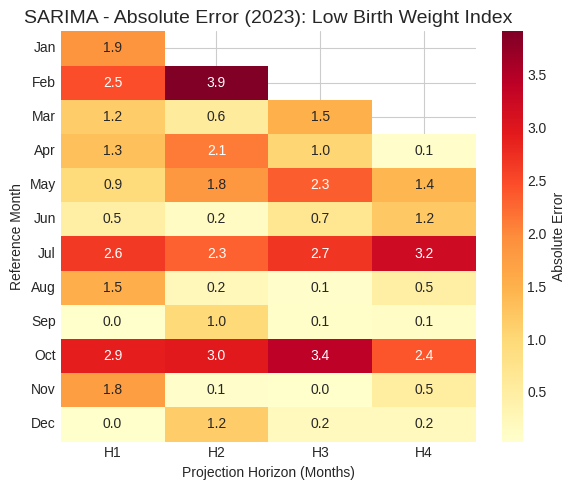

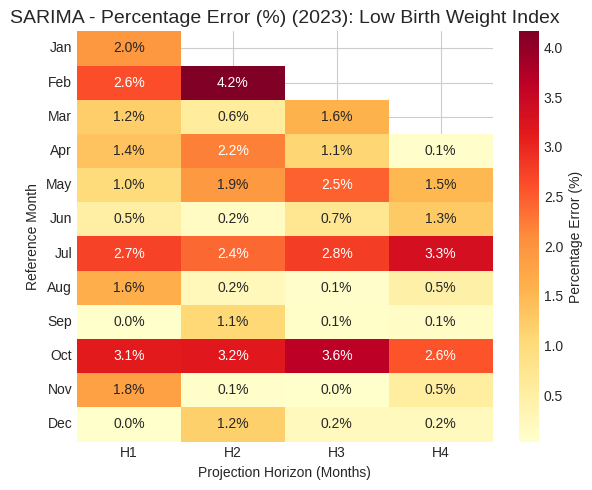

In [23]:
plot_error_heatmap(heat_abs, TARGET_LABEL, error_type="Absolute")
plot_error_heatmap(heat_pct, TARGET_LABEL, error_type="Percentage")

## 9. LSTM Modeling

In [24]:
# Unified LSTM training, evaluation, and wrappers are implemented in abep_forecasting.lstm.


00:34:24 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_baseline_metrics_2023.csv
00:34:24 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_baseline_comparison_2023.csv


Low Birth Weight Results
MAE : 3.9643767038981124
RMSE: 4.302717740211577
MAPE: 4.159582311594284


,Month,Actual,Predicted,Absolute Error
0,2023-01,94.9,91.8535,3.0465
1,2023-02,93.8,91.6478,2.1522
2,2023-03,95.0,91.4338,3.5662
3,2023-04,95.8,91.2395,4.5605
4,2023-05,94.6,91.0119,3.5881
5,2023-06,94.2,90.8795,3.3205
6,2023-07,96.4,90.6941,5.7059
7,2023-08,94.2,90.5350,3.6650
8,2023-09,91.8,90.4127,1.3873
9,2023-10,93.2,90.2669,2.9331


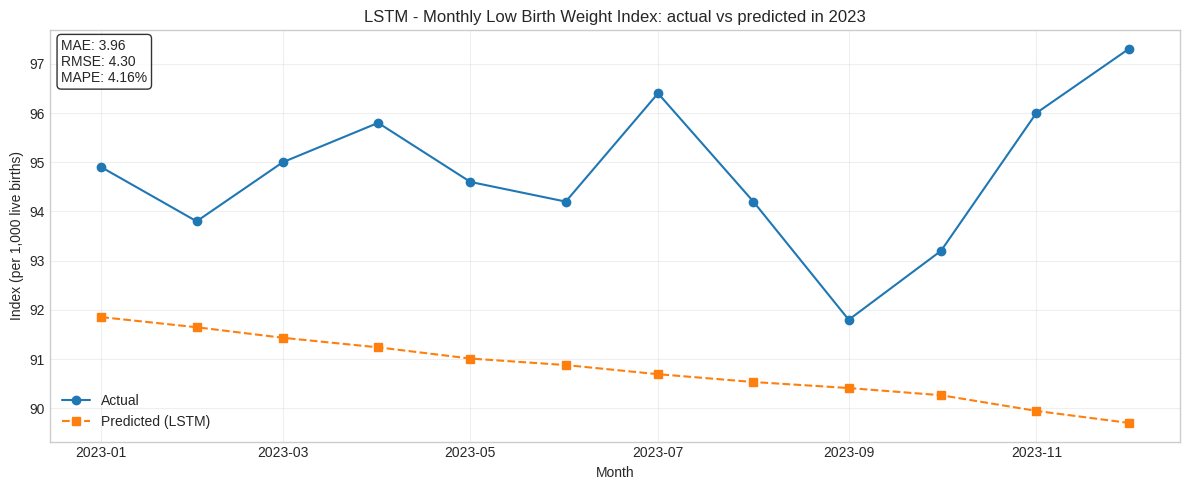

In [25]:
# LSTM - Main Execution
lstm_result = run_lstm_pipeline_split(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"LSTM - Monthly {TARGET_LABEL}: actual vs predicted in 2023",
    ylabel=Y_AXIS_LABEL,
    lookback=12,
    units=32,
    dropout=0.0,
    learning_rate=0.001,
    epochs=250,
    batch_size=8,
    seed=42,
    plot=False
)

lstm_baseline_metrics = model_metrics_frame("LSTM baseline", lstm_result)
save_table(lstm_baseline_metrics, "lstm_baseline_metrics_2023")
save_table(lstm_result["compare_2023"], "lstm_baseline_comparison_2023")

print(f"{indicator_choice} Results")
print("MAE :", lstm_result["mae"])
print("RMSE:", lstm_result["rmse"])
print("MAPE:", lstm_result["mape"])
display(lstm_result["compare_2023"])

# --- Custom Plotting ---
y_true = lstm_result["y_true"]
y_pred = lstm_result["y_pred"]

plt.figure(figsize=(12, 5))
plt.plot(y_true.index, y_true.values, label="Actual", marker="o")
plt.plot(y_pred.index, y_pred.values, label="Predicted (LSTM)", marker="s", linestyle="--")

plt.title(f"LSTM - Monthly {TARGET_LABEL}: actual vs predicted in 2023")
plt.xlabel("Month")
plt.ylabel(Y_AXIS_LABEL)
plt.grid(True, alpha=0.3)
plt.legend()

textstr = f"MAE: {lstm_result['mae']:.2f}\nRMSE: {lstm_result['rmse']:.2f}\nMAPE: {lstm_result['mape']:.2f}%"
props = dict(boxstyle="round", facecolor="white", alpha=0.8)
plt.text(0.01, 0.98, textstr, transform=plt.gca().transAxes, va="top", ha="left", bbox=props)
plt.tight_layout()
plt.show()


### 9.1 LSTM Hyperparameter Grid Search


#### 9.1.1 Basic Hyperparameter Tuning


In [26]:
results_grid, best_lstm, best_params_lstm = grid_search_lstm_split(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"LSTM - {TARGET_LABEL}: actual vs predicted in 2023",
    ylabel=Y_AXIS_LABEL,
    lookback_values=(6, 12, 18, 24),
    units_values=(16, 32, 64),
    learning_rate_values=(1e-3, 5e-4, 1e-4),
    dropout=0.0,
    epochs=250,
    batch_size=8,
    seed=42,
    sort_by="rmse",
    use_validation=True,
    verbose=True
)

00:34:25 | INFO | abep_forecasting | Total LSTM combinations: 36
00:34:25 | INFO | abep_forecasting | LSTM grid [1/36]: lookback=6, units=16, learning_rate=0.001
00:34:30 | INFO | abep_forecasting | LSTM grid [2/36]: lookback=6, units=16, learning_rate=0.0005
00:34:36 | INFO | abep_forecasting | LSTM grid [3/36]: lookback=6, units=16, learning_rate=0.0001
00:34:49 | INFO | abep_forecasting | LSTM grid [4/36]: lookback=6, units=32, learning_rate=0.001
00:34:54 | INFO | abep_forecasting | LSTM grid [5/36]: lookback=6, units=32, learning_rate=0.0005
00:35:00 | INFO | abep_forecasting | LSTM grid [6/36]: lookback=6, units=32, learning_rate=0.0001
00:35:11 | INFO | abep_forecasting | LSTM grid [7/36]: lookback=6, units=64, learning_rate=0.001
00:35:16 | INFO | abep_forecasting | LSTM grid [8/36]: lookback=6, units=64, learning_rate=0.0005
00:35:22 | INFO | abep_forecasting | LSTM grid [9/36]: lookback=6, units=64, learning_rate=0.0001
00:35:30 | INFO | abep_forecasting | LSTM grid [10/36]: 

In [27]:
logger.info("Best hyperparameters selected for %s", indicator_choice)
logger.info("Best LSTM parameters: %s", best_params_lstm)

save_table(results_grid, "lstm_grid_search")
save_json(best_params_lstm, "lstm_best_hyperparameters")

display(results_grid.head(10))


00:40:18 | INFO | abep_forecasting | Best hyperparameters selected for Low Birth Weight
00:40:18 | INFO | abep_forecasting | Best LSTM parameters: {'lookback': 24, 'units': 64, 'dropout': 0.0, 'learning_rate': 0.001, 'epochs': 250, 'batch_size': 8, 'seed': 42, 'mae': 1.407331720987956, 'rmse': 1.6761434092186318, 'mape': 1.4783739746780475, 'status': 'ok'}
00:40:18 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_grid_search.csv
00:40:18 | INFO | abep_forecasting | Saved JSON: output/tables/low_birth_weight_lstm_best_hyperparameters.json


,lookback,units,dropout,learning_rate,epochs,batch_size,seed,mae,rmse,mape,status
0,24,64,0.0,0.0010,250,8,42,1.407332,1.676143,1.478374,ok
1,18,64,0.0,0.0010,250,8,42,1.310460,1.827261,1.400444,ok
2,18,64,0.0,0.0005,250,8,42,1.585700,1.890443,1.661948,ok
3,24,64,0.0,0.0005,250,8,42,1.900491,2.199513,1.990871,ok
4,18,32,0.0,0.0001,250,8,42,2.170716,2.398401,2.279989,ok
5,12,64,0.0,0.0010,250,8,42,2.303607,2.693839,2.410667,ok
6,18,32,0.0,0.0010,250,8,42,2.645131,2.999229,2.769678,ok
7,24,32,0.0,0.0010,250,8,42,2.925115,3.266653,3.064196,ok
8,18,64,0.0,0.0001,250,8,42,3.077993,3.419565,3.225287,ok
9,24,64,0.0,0.0001,250,8,42,3.149120,3.466470,3.300643,ok


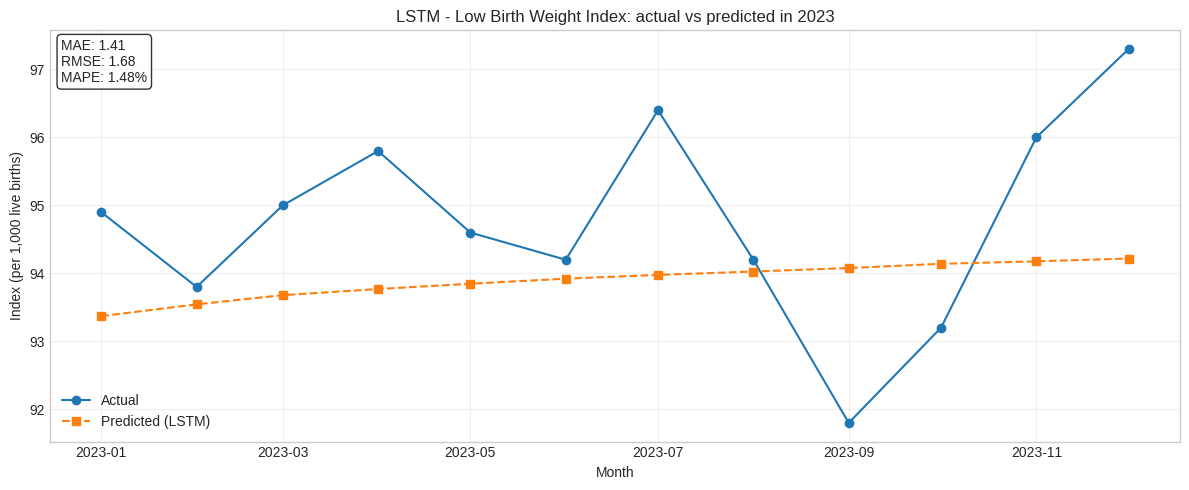

00:40:23 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_best_grid_metrics_2023.csv
00:40:23 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_best_grid_comparison_2023.csv


Low Birth Weight - Best Model Results
MAE : 1.407331720987956
RMSE: 1.6761434092186318
MAPE: 1.4783739746780475


,Month,Actual,Predicted,Absolute Error
0,2023-01,94.9,93.3707,1.5293
1,2023-02,93.8,93.5439,0.2561
2,2023-03,95.0,93.6790,1.3210
3,2023-04,95.8,93.7693,2.0307
4,2023-05,94.6,93.8472,0.7528
5,2023-06,94.2,93.9214,0.2786
6,2023-07,96.4,93.9772,2.4228
7,2023-08,94.2,94.0267,0.1733
8,2023-09,91.8,94.0779,2.2779
9,2023-10,93.2,94.1403,0.9403


In [28]:
best_lstm_final = run_lstm_pipeline_split(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"LSTM - {TARGET_LABEL}: actual vs predicted in 2023",
    ylabel=Y_AXIS_LABEL,
    lookback=best_params_lstm["lookback"],
    units=best_params_lstm["units"],
    dropout=best_params_lstm["dropout"],
    learning_rate=best_params_lstm["learning_rate"],
    epochs=best_params_lstm["epochs"],
    batch_size=best_params_lstm["batch_size"],
    seed=best_params_lstm["seed"],
    use_validation=True,
    plot=True
)

best_lstm_metrics = model_metrics_frame("LSTM best grid model", best_lstm_final)
save_table(best_lstm_metrics, "lstm_best_grid_metrics_2023")
save_table(best_lstm_final["compare_2023"], "lstm_best_grid_comparison_2023")

print(f"{indicator_choice} - Best Model Results")
print("MAE :", best_lstm_final["mae"])
print("RMSE:", best_lstm_final["rmse"])
print("MAPE:", best_lstm_final["mape"])
display(best_lstm_final["compare_2023"])


#### 9.1.2 Regularization and Overfitting Control


In [29]:
# Regularized LSTM wrappers are implemented in abep_forecasting.lstm.


In [30]:
base_params = {
    "lookback": best_params_lstm["lookback"],
    "units": best_params_lstm["units"],
    "learning_rate": best_params_lstm["learning_rate"],
    "epochs": best_params_lstm["epochs"],
    "batch_size": best_params_lstm["batch_size"],
    "seed": best_params_lstm["seed"]
}

logger.info("Base parameters for regularization search: %s", base_params)

00:40:23 | INFO | abep_forecasting | Base parameters for regularization search: {'lookback': 24, 'units': 64, 'learning_rate': 0.001, 'epochs': 250, 'batch_size': 8, 'seed': 42}


In [31]:
# LSTM regularization grid search is implemented in abep_forecasting.lstm.


In [32]:
results_reg, best_lstm_reg, best_params_reg = grid_search_lstm_regularization(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"Regularized LSTM - Monthly {TARGET_LABEL}: actual vs predicted in 2023",
    ylabel=Y_AXIS_LABEL,
    base_params=base_params,
    dropout_values=(0.0, 0.1, 0.2),
    l2_values=(0.0, 1e-5, 1e-4, 1e-3),
    patience_values=(10, 20, 30),
    early_stopping_values=(True,),
    use_validation=True,
    sort_by="rmse",
    verbose=True
)

logger.info("Best regularization parameters selected for %s", indicator_choice)
logger.info("Best regularization parameters: %s", best_params_reg)

save_table(results_reg, "lstm_regularization_grid_search")
save_json(best_params_reg, "lstm_best_regularization_parameters")

display(results_reg.head(10))


00:40:23 | INFO | abep_forecasting | Total regularization combinations: 36
00:40:23 | INFO | abep_forecasting | Regularization grid [1/36]: dropout=0.0, l2_lambda=0.0, patience=10, early_stopping=True
00:40:27 | INFO | abep_forecasting | Regularization grid [2/36]: dropout=0.0, l2_lambda=0.0, patience=20, early_stopping=True
00:40:32 | INFO | abep_forecasting | Regularization grid [3/36]: dropout=0.0, l2_lambda=0.0, patience=30, early_stopping=True
00:40:40 | INFO | abep_forecasting | Regularization grid [4/36]: dropout=0.0, l2_lambda=1e-05, patience=10, early_stopping=True
00:40:44 | INFO | abep_forecasting | Regularization grid [5/36]: dropout=0.0, l2_lambda=1e-05, patience=20, early_stopping=True
00:40:49 | INFO | abep_forecasting | Regularization grid [6/36]: dropout=0.0, l2_lambda=1e-05, patience=30, early_stopping=True
00:40:56 | INFO | abep_forecasting | Regularization grid [7/36]: dropout=0.0, l2_lambda=0.0001, patience=10, early_stopping=True
00:40:59 | INFO | abep_forecasting

,lookback,units,learning_rate,epochs,batch_size,seed,dropout,l2_lambda,patience,early_stopping,mae,rmse,mape,status
0,24,64,0.001,250,8,42,0.0,0.00000,10,True,1.407332,1.676143,1.478374,ok
1,24,64,0.001,250,8,42,0.0,0.00000,20,True,1.407332,1.676143,1.478374,ok
2,24,64,0.001,250,8,42,0.0,0.00000,30,True,1.407332,1.676143,1.478374,ok
3,24,64,0.001,250,8,42,0.0,0.00001,10,True,1.411162,1.679389,1.482351,ok
4,24,64,0.001,250,8,42,0.0,0.00001,20,True,1.411162,1.679389,1.482351,ok
5,24,64,0.001,250,8,42,0.0,0.00001,30,True,1.411162,1.679389,1.482351,ok
6,24,64,0.001,250,8,42,0.0,0.00010,10,True,1.515557,1.774827,1.590730,ok
7,24,64,0.001,250,8,42,0.0,0.00010,20,True,1.515557,1.774827,1.590730,ok
8,24,64,0.001,250,8,42,0.0,0.00010,30,True,1.515557,1.774827,1.590730,ok
9,24,64,0.001,250,8,42,0.1,0.00000,10,True,3.049050,3.399327,3.194626,ok


00:47:44 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_regularized_metrics_2023.csv
00:47:44 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_regularized_comparison_2023.csv


Low Birth Weight - Best Regularized Model Results
MAE : 1.407331720987956
RMSE: 1.6761434092186318
MAPE: 1.4783739746780475


,Month,Actual,Predicted,Absolute Error
0,2023-01,94.9,93.3707,1.5293
1,2023-02,93.8,93.5439,0.2561
2,2023-03,95.0,93.6790,1.3210
3,2023-04,95.8,93.7693,2.0307
4,2023-05,94.6,93.8472,0.7528
5,2023-06,94.2,93.9214,0.2786
6,2023-07,96.4,93.9772,2.4228
7,2023-08,94.2,94.0267,0.1733
8,2023-09,91.8,94.0779,2.2779
9,2023-10,93.2,94.1403,0.9403


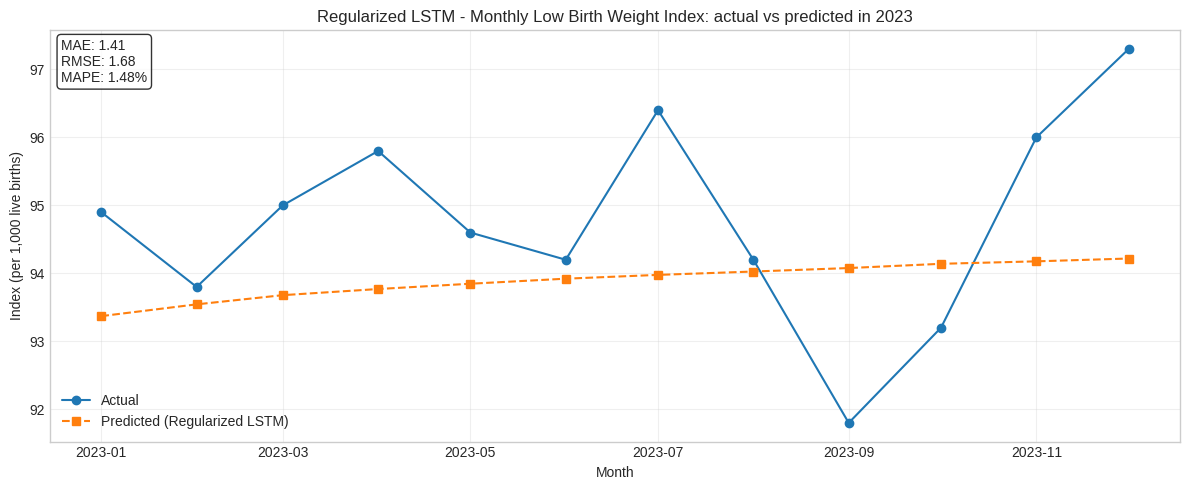

In [33]:
best_lstm_reg_final = run_lstm_pipeline_split_regularized(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"Regularized LSTM - Monthly {TARGET_LABEL}: actual vs predicted in 2023",
    ylabel=Y_AXIS_LABEL,
    lookback=best_params_reg["lookback"],
    units=best_params_reg["units"],
    dropout=best_params_reg["dropout"],
    learning_rate=best_params_reg["learning_rate"],
    l2_lambda=best_params_reg["l2_lambda"],
    epochs=best_params_reg["epochs"],
    batch_size=best_params_reg["batch_size"],
    seed=best_params_reg["seed"],
    use_validation=True,
    early_stopping=best_params_reg["early_stopping"],
    patience=best_params_reg["patience"],
    plot=False
)

best_lstm_reg_metrics = model_metrics_frame("LSTM regularized", best_lstm_reg_final)
save_table(best_lstm_reg_metrics, "lstm_regularized_metrics_2023")
save_table(best_lstm_reg_final["compare_2023"], "lstm_regularized_comparison_2023")

print(f"{indicator_choice} - Best Regularized Model Results")
print("MAE :", best_lstm_reg_final["mae"])
print("RMSE:", best_lstm_reg_final["rmse"])
print("MAPE:", best_lstm_reg_final["mape"])
display(best_lstm_reg_final["compare_2023"])

# --- Custom Plotting ---
y_true_reg = best_lstm_reg_final["y_true"]
y_pred_reg = best_lstm_reg_final["y_pred"]

plt.figure(figsize=(12, 5))
plt.plot(y_true_reg.index, y_true_reg.values, label="Actual", marker="o")
plt.plot(y_pred_reg.index, y_pred_reg.values, label="Predicted (Regularized LSTM)", marker="s", linestyle="--")

plt.title(f"Regularized LSTM - Monthly {TARGET_LABEL}: actual vs predicted in 2023")
plt.xlabel("Month")
plt.ylabel(Y_AXIS_LABEL)
plt.grid(True, alpha=0.3)
plt.legend()

textstr_reg = f"MAE: {best_lstm_reg_final['mae']:.2f}\nRMSE: {best_lstm_reg_final['rmse']:.2f}\nMAPE: {best_lstm_reg_final['mape']:.2f}%"
props = dict(boxstyle="round", facecolor="white", alpha=0.8)
plt.text(0.01, 0.98, textstr_reg, transform=plt.gca().transAxes, va="top", ha="left", bbox=props)

plt.tight_layout()
plt.show()


#### 9.1.3 Series Transformations


In [34]:
# Transformed LSTM wrappers are implemented in abep_forecasting.lstm.


In [35]:
base_params_transform = {
    "lookback": best_params_reg["lookback"],
    "units": best_params_reg["units"],
    "dropout": best_params_reg["dropout"],
    "learning_rate": best_params_reg["learning_rate"],
    "l2_lambda": best_params_reg["l2_lambda"],
    "epochs": best_params_reg["epochs"],
    "batch_size": best_params_reg["batch_size"],
    "seed": best_params_reg["seed"],
    "early_stopping": best_params_reg["early_stopping"],
    "patience": best_params_reg["patience"]
}

logger.info("Parameters for transformation search: %s", base_params_transform)

00:47:44 | INFO | abep_forecasting | Parameters for transformation search: {'lookback': 24, 'units': 64, 'dropout': 0.0, 'learning_rate': 0.001, 'l2_lambda': 0.0, 'epochs': 250, 'batch_size': 8, 'seed': 42, 'early_stopping': True, 'patience': 10}


In [36]:
results_transform = []

for transform_name in ["none", "log1p"]:
    result = run_lstm_pipeline_split_regularized_transformed(
        split_data=split_data,
        value_col=VALUE_COL,
        title=f"LSTM - {TARGET_LABEL} (transform={transform_name})",
        ylabel=Y_AXIS_LABEL,
        lookback=base_params_transform["lookback"],
        units=base_params_transform["units"],
        dropout=base_params_transform["dropout"],
        learning_rate=base_params_transform["learning_rate"],
        l2_lambda=base_params_transform["l2_lambda"],
        transform=transform_name,
        epochs=base_params_transform["epochs"],
        batch_size=base_params_transform["batch_size"],
        seed=base_params_transform["seed"],
        use_validation=True,
        early_stopping=base_params_transform["early_stopping"],
        patience=base_params_transform["patience"],
        plot=False
    )

    results_transform.append({
        "transform": transform_name,
        "mae": result["mae"],
        "rmse": result["rmse"],
        "mape": result["mape"]
    })

results_transform_df = pd.DataFrame(results_transform).sort_values(
    by=["rmse", "mae", "mape"],
    ascending=True
).reset_index(drop=True)

save_table(results_transform_df, "lstm_transform_search")
display(results_transform_df)


00:47:51 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_transform_search.csv


,transform,mae,rmse,mape
0,log1p,1.338992,1.619138,1.407613
1,none,1.407332,1.676143,1.478374


In [37]:
best_transform = results_transform_df.iloc[0]["transform"]
logger.info("Best series transformation: %s", best_transform)

00:47:51 | INFO | abep_forecasting | Best series transformation: log1p


00:47:55 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_best_transform_metrics_2023.csv
00:47:55 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_best_transform_comparison_2023.csv
00:47:55 | INFO | abep_forecasting | Saved JSON: output/tables/low_birth_weight_lstm_best_transform.json


Low Birth Weight - Best Model with Transformation
Transformation: log1p
MAE : 1.3389922484295258
RMSE: 1.6191375840935194
MAPE: 1.4076125243056097


,Month,Actual,Predicted,Absolute Error
0,2023-01,94.9,93.4333,1.4667
1,2023-02,93.8,93.6137,0.1863
2,2023-03,95.0,93.7588,1.2412
3,2023-04,95.8,93.8588,1.9412
4,2023-05,94.6,93.9476,0.6524
5,2023-06,94.2,94.0337,0.1663
6,2023-07,96.4,94.1008,2.2992
7,2023-08,94.2,94.1617,0.0383
8,2023-09,91.8,94.2248,2.4248
9,2023-10,93.2,94.3007,1.1007


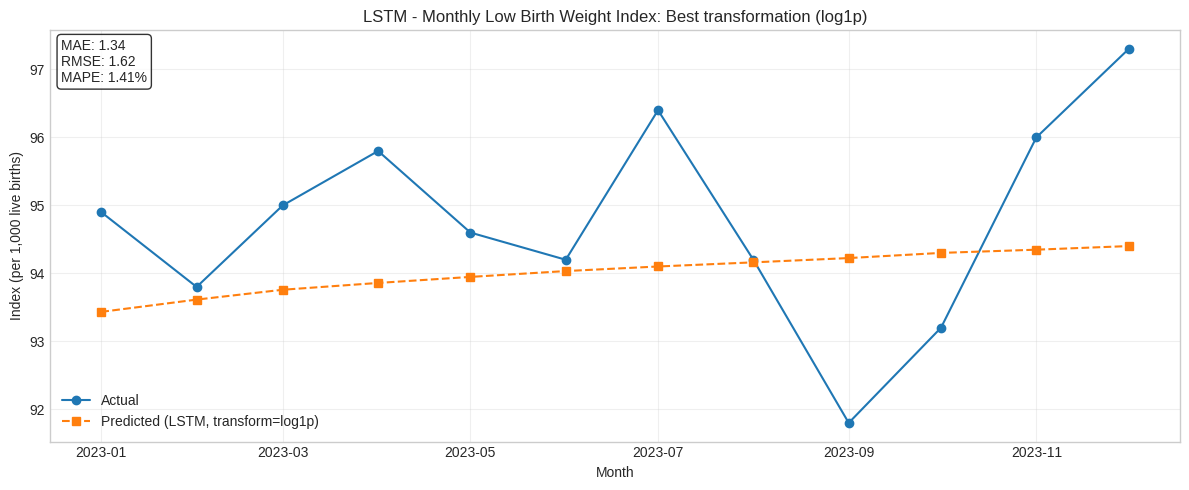

In [38]:
best_lstm_transform_final = run_lstm_pipeline_split_regularized_transformed(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"LSTM - Monthly {TARGET_LABEL}: Best transformation ({best_transform})",
    ylabel=Y_AXIS_LABEL,
    lookback=base_params_transform["lookback"],
    units=base_params_transform["units"],
    dropout=base_params_transform["dropout"],
    learning_rate=base_params_transform["learning_rate"],
    l2_lambda=base_params_transform["l2_lambda"],
    transform=best_transform,
    epochs=base_params_transform["epochs"],
    batch_size=base_params_transform["batch_size"],
    seed=base_params_transform["seed"],
    use_validation=True,
    early_stopping=base_params_transform["early_stopping"],
    patience=base_params_transform["patience"],
    plot=False
)

best_lstm_transform_metrics = model_metrics_frame("LSTM best transformation", best_lstm_transform_final)
save_table(best_lstm_transform_metrics, "lstm_best_transform_metrics_2023")
save_table(best_lstm_transform_final["compare_2023"], "lstm_best_transform_comparison_2023")
save_json({"best_transform": best_transform}, "lstm_best_transform")

print(f"{indicator_choice} - Best Model with Transformation")
print("Transformation:", best_transform)
print("MAE :", best_lstm_transform_final["mae"])
print("RMSE:", best_lstm_transform_final["rmse"])
print("MAPE:", best_lstm_transform_final["mape"])
display(best_lstm_transform_final["compare_2023"])

# --- Custom Plotting ---
y_true_tf = best_lstm_transform_final["y_true"]
y_pred_tf = best_lstm_transform_final["y_pred"]

plt.figure(figsize=(12, 5))
plt.plot(y_true_tf.index, y_true_tf.values, label="Actual", marker="o")
plt.plot(y_pred_tf.index, y_pred_tf.values, label=f"Predicted (LSTM, transform={best_transform})", marker="s", linestyle="--")

plt.title(f"LSTM - Monthly {TARGET_LABEL}: Best transformation ({best_transform})")
plt.xlabel("Month")
plt.ylabel(Y_AXIS_LABEL)
plt.grid(True, alpha=0.3)
plt.legend()

textstr_tf = f"MAE: {best_lstm_transform_final['mae']:.2f}\nRMSE: {best_lstm_transform_final['rmse']:.2f}\nMAPE: {best_lstm_transform_final['mape']:.2f}%"
plt.text(0.01, 0.98, textstr_tf, transform=plt.gca().transAxes, va="top", ha="left", bbox=props)

plt.tight_layout()
plt.show()


## 10. Multi-Horizon Forecasts with LSTM


In [39]:
# Multi-horizon recursive forecasts and plots are implemented in abep_forecasting.lstm and abep_forecasting.plots.


In [40]:
# Multi-horizon LSTM evaluation is implemented in abep_forecasting.lstm.evaluate_lstm_multi_horizon.


In [41]:
# LSTM rolling output tables are implemented in abep_forecasting.plots.generate_lstm_rolling_outputs.


In [42]:
# LSTM rolling plots and heatmaps are implemented in abep_forecasting.plots.


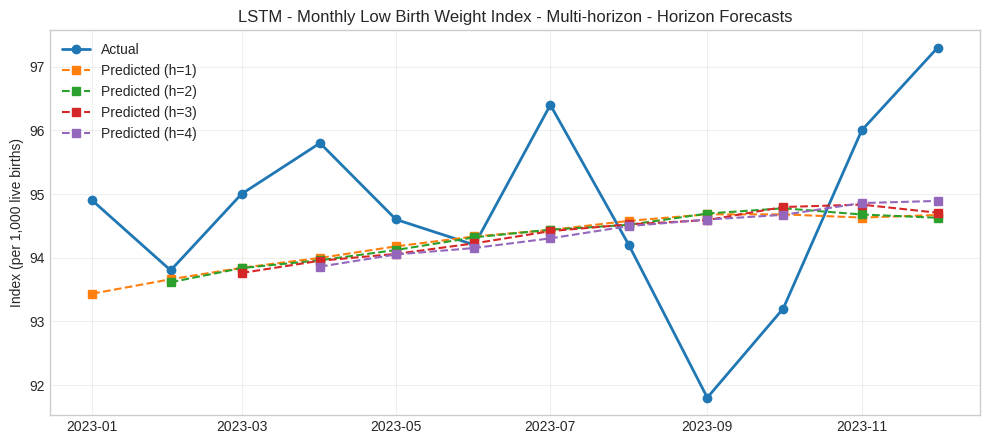

00:48:01 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_multi_horizon_metrics_2023.csv
00:48:01 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_multi_horizon_forecasts_2023.csv


,Horizon,N,MAE,RMSE,MAPE
0,1,12,1.319162,1.587830,1.390207
1,2,11,1.321053,1.615761,1.392357
2,3,10,1.410854,1.664726,1.486751
3,4,9,1.417196,1.688704,1.493627


00:48:01 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_multi_horizon_rolling_forecasts_2023.csv
00:48:01 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_lstm_multi_horizon_absolute_errors_2023.csv


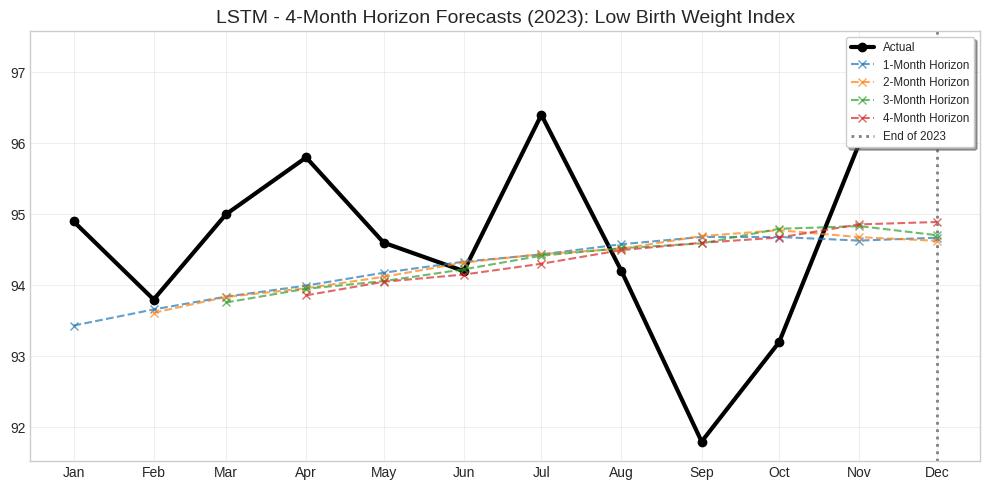

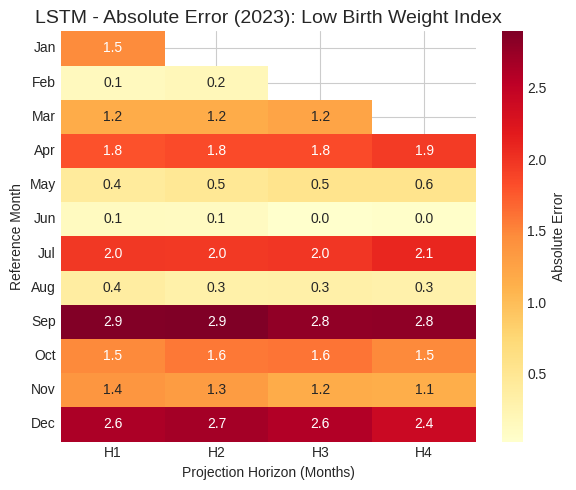

In [43]:
# Execute the optimized multi-horizon LSTM evaluation using the best available parameters.
params = best_params_reg if "best_params_reg" in globals() else base_params_transform

lstm_multi_result = evaluate_lstm_multi_horizon(
    split_data=split_data,
    value_col=VALUE_COL,
    title=f"LSTM - Monthly {TARGET_LABEL} - Multi-horizon",
    ylabel=Y_AXIS_LABEL,
    lookback=params["lookback"],
    units=params["units"],
    dropout=params["dropout"],
    learning_rate=params["learning_rate"],
    l2_lambda=params.get("l2_lambda", 0.0),
    transform=best_transform if "best_transform" in globals() else "none",
    epochs=params["epochs"],
    batch_size=params["batch_size"],
    seed=params["seed"],
    use_validation=True,
    early_stopping=True,
    patience=params.get("patience", 10),
    horizons=(1, 2, 3, 4),
    plot=True,
)

save_table(lstm_multi_result["horizon_metrics"], "lstm_multi_horizon_metrics_2023")
save_table(lstm_multi_result["forecasts_df"], "lstm_multi_horizon_forecasts_2023")

display(lstm_multi_result["horizon_metrics"])
lstm_roll_df, lstm_heat_abs = generate_lstm_rolling_outputs(lstm_multi_result, year=TEST_YEAR, steps=4)
save_table(lstm_roll_df, "lstm_multi_horizon_rolling_forecasts_2023", index=True)
save_table(lstm_heat_abs, "lstm_multi_horizon_absolute_errors_2023")
plot_lstm_rolling_comparison(split_data.full[VALUE_COL], lstm_roll_df, TARGET_LABEL)
plot_lstm_error_heatmap(lstm_heat_abs, TARGET_LABEL)


## 11. Final Model Comparison

Consolidate SARIMA and LSTM validation metrics into one ranked table. The comparison uses the 2023 holdout period whenever available; for the multi-horizon LSTM, the one-month horizon is included because it is directly comparable with one-step monthly forecasts.

In [44]:
final_model_comparison = _build_final_model_comparison(globals())

if not final_model_comparison.empty:
    save_table(final_model_comparison, "final_model_comparison_2023")
    display(Markdown("### Final Model Comparison - 2023 Holdout"))
    display(final_model_comparison)
else:
    display(Markdown("### Final Model Comparison - no model metrics available yet"))


00:48:01 | INFO | abep_forecasting | Saved table: output/tables/low_birth_weight_final_model_comparison_2023.csv


### Final Model Comparison - 2023 Holdout

,Rank by RMSE,Model,Variant,MAE,RMSE,MAPE (%),Notes
0,1,LSTM,Multi-horizon H1,1.3192,1.5878,1.3902,One-month horizon from rolling multi-horizon e...
1,2,LSTM,Best transformation,1.3390,1.6191,1.4076,Transform=log1p
2,3,LSTM,Best grid model,1.4073,1.6761,1.4784,Best baseline grid-search configuration
3,3,LSTM,Regularized,1.4073,1.6761,1.4784,Dropout/L2/early-stopping configuration
4,5,SARIMA,Selected grid model,1.2961,1.8295,1.3746,"SARIMA(0, 1, 2)x(2, 0, 2, 12)"
5,6,LSTM,Baseline,3.9644,4.3027,4.1596,Manual baseline parameters
